# 🔧 Environment Setup

Install core libraries for fine-tuning RoBERTa-Tagalog-base on a symptom→disease classification task.

**Main Packages**
- `transformers` – model + Trainer utilities
- `datasets` – dataset loading & mapping
- `torch` – deep learning backend
- `scikit-learn` – metrics & evaluation
- `optuna` – hyperparameter optimization
- `evaluate` – standardized metric interface
- `wandb` – experiment tracking
- `pandas`, `numpy` – data manipulation
- `matplotlib`, `seaborn` – plotting

Run once per environment. Dependencies are kept minimal for fast startup.

In [1]:
%pip install transformers datasets torch scikit-learn pandas numpy matplotlib seaborn optuna evaluate wandb huggingface_hub

Note: you may need to restart the kernel to use updated packages.


# 📂 Save Path Setup

Define the local directory where the trained model will be saved.


In [2]:
import os

# Define local save path
drive_save_path = './final_model'

# Create directory if it doesn't exist
os.makedirs(drive_save_path, exist_ok=True)
print(f"✅ Directory ready: {drive_save_path}")


✅ Directory ready: ./final_model


# 🔑 Weights & Biases Authentication

Login to W&B for experiment tracking.

In [3]:
import wandb
import os

# Set your W&B API key
wandb.login(key="45e817fe1587cb0ebc93b08f07fbba6c36197288")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /home/notlath/.netrc
wandb: Currently logged in as: qltpagsuguiron (qltpagsuguiron-technological-institute-of-the-philippines) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# 📊 Dataset Loading & Preprocessing

Load the Filipino symptom→disease dataset from Hugging Face and create clean train/validation/test splits.

**Key Steps:**
1. Load dataset from `notlath/fil_dataset`
2. Extract text and labels
3. Create label mappings (label2id, id2label)
4. Split: 70% train / 15% validation / 15% test (stratified, seed=42)
5. **Verify no data leakage** between splits

**Output:** Clean `dataset` dict with three splits ready for tokenization.

In [4]:
from datasets import load_dataset, DatasetDict, Features, ClassLabel, Value, concatenate_datasets
from transformers import set_seed
import pandas as pd

set_seed(42)

# Load the dataset from Hugging Face
print("Loading dataset from Hugging Face...")
full_dataset = load_dataset("notlath/fil_dataset")

print(f"Available splits: {list(full_dataset.keys())}")

# Combine all splits back into one to avoid re-splitting an already-split subset
all_splits = list(full_dataset.values())
raw_data = concatenate_datasets(all_splits)

print(f"Loaded {len(raw_data)} samples (all splits combined)")
print(f"Columns: {raw_data.column_names}")

# Get label names — prefer ClassLabel feature names over raw values to avoid integer labels
label_feature = raw_data.features.get('label')
if hasattr(label_feature, 'names'):
    # Dataset uses ClassLabel: names are stored in the feature metadata
    unique_labels = sorted([l for l in label_feature.names if l != 'label'])
    int_to_str = {i: name for i, name in enumerate(label_feature.names)}
    print(f"\nLabel names read from ClassLabel feature: {unique_labels}")
else:
    # Fallback: labels are plain strings
    unique_labels = sorted([l for l in set(raw_data['label']) if l != 'label'])
    int_to_str = None
    print(f"\nRaw unique labels found: {unique_labels}")

label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}

print(f"\nFound {len(unique_labels)} valid labels:")
for label in unique_labels:
    print(f"  - {label}")

# Convert labels to integers and filter out invalid rows
def map_labels(example):
    label = example['label']
    # Convert integer ClassLabel index to string name if needed
    if int_to_str is not None and isinstance(label, int):
        label = int_to_str[label]
    if label == 'label':
        return None
    return {
        'text': example['text'],
        'labels': label2id[label]
    }

# Filter invalid rows first, then map labels
processed_data = raw_data.filter(lambda x: x['label'] != 'label')

# Keep only the fields needed downstream: text + labels
processed_data = processed_data.map(
    map_labels,
    remove_columns=raw_data.column_names
)

print(f"Processed {len(processed_data)} valid samples")

# Cast labels to ClassLabel feature type for stratified splitting
features = Features({
    'text': Value('string'),
    'labels': ClassLabel(names=unique_labels)
})
processed_data = processed_data.cast(features)

print(f"✅ Labels converted to ClassLabel feature type")

# Create stratified splits: 70% train, 15% val, 15% test
# First split: 70% train, 30% temp
train_test = processed_data.train_test_split(
    test_size=0.3,
    seed=42,
    stratify_by_column='labels'
)

# Second split: split the 30% into 15% val, 15% test
val_test = train_test['test'].train_test_split(
    test_size=0.5,
    seed=42,
    stratify_by_column='labels'
)

# Create final dataset dictionary
dataset = DatasetDict({
    'train': train_test['train'],
    'validation': val_test['train'],
    'test': val_test['test']
})

print(f"\n✅ Dataset splits created:")
print(f"   Train:      {len(dataset['train'])} samples")
print(f"   Validation: {len(dataset['validation'])} samples")
print(f"   Test:       {len(dataset['test'])} samples")


/home/notlath/Downloads/model-training-fil/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading dataset from Hugging Face...


Generating test split: 100%|██████████| 900/900 [00:00<00:00, 516398.58 examples/s]


Available splits: ['train', 'validation', 'test']
Loaded 6000 samples (all splits combined)
Columns: ['label', 'text']

Label names read from ClassLabel feature: ['Dengue', 'Diarrhea', 'Influenza', 'Measles', 'Pneumonia', 'Typhoid']

Found 6 valid labels:
  - Dengue
  - Diarrhea
  - Influenza
  - Measles
  - Pneumonia
  - Typhoid


Map: 100%|██████████| 6000/6000 [00:00<00:00, 20186.53 examples/s]


Processed 6000 valid samples


Casting the dataset: 100%|██████████| 6000/6000 [00:00<00:00, 497308.99 examples/s]


✅ Labels converted to ClassLabel feature type

✅ Dataset splits created:
   Train:      4200 samples
   Validation: 900 samples
   Test:       900 samples


# 🔍 Data Integrity Check

Verify there's no overlap between train/validation/test splits to ensure data leakage is prevented.

In [5]:
def check_overlap(split1, split2, name1, name2):
    """Check for overlapping text samples between two splits."""
    set1 = set(split1['text'])
    set2 = set(split2['text'])
    overlap = set1.intersection(set2)

    if overlap:
        print(f"❌ WARNING: {len(overlap)} overlapping samples between {name1} and {name2}")
        for idx, sample in enumerate(sorted(overlap), 1):
            print(f"   {idx}. {sample}")
        return len(overlap)
    else:
        print(f"✅ No overlap between {name1} and {name2}")
        return 0

print("Checking for data leakage...\n")
total_overlap = 0
total_overlap += check_overlap(dataset['train'], dataset['validation'], 'train', 'validation')
total_overlap += check_overlap(dataset['train'], dataset['test'], 'train', 'test')
total_overlap += check_overlap(dataset['validation'], dataset['test'], 'validation', 'test')

if total_overlap == 0:
    print(f"\n✅ Data integrity verified: No leakage detected!")
else:
    print(f"\n❌ Total overlapping samples: {total_overlap}")


Checking for data leakage...

✅ No overlap between train and validation
✅ No overlap between train and test
✅ No overlap between validation and test

✅ Data integrity verified: No leakage detected!


# 🔤 Tokenization

Tokenize all text samples using RoBERTa-Tagalog tokenizer with truncation and padding.

**Model:** `jcblaise/roberta-tagalog-base`

The tokenizer converts text to input_ids and attention_mask tensors ready for model training.

In [6]:
from transformers import AutoTokenizer

model_id = "jcblaise/roberta-tagalog-base"

print(f"Loading tokenizer: {model_id}")
tokenizer = AutoTokenizer.from_pretrained(model_id)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding=False,  # Dynamic padding will be handled by data collator
        max_length=512
    )

# Apply tokenization to all splits
print("\nTokenizing datasets...")
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=['text']
)

print("\n✅ Tokenization complete")
print(f"Features: {tokenized_dataset['train'].features}")
print(f"\nSample tokenized input:")
print(f"  input_ids shape: {len(tokenized_dataset['train'][0]['input_ids'])} tokens")
print(f"  attention_mask shape: {len(tokenized_dataset['train'][0]['attention_mask'])} tokens")

Loading tokenizer: jcblaise/roberta-tagalog-base

Tokenizing datasets...


Map: 100%|██████████| 900/900 [00:00<00:00, 36981.37 examples/s]


✅ Tokenization complete
Features: {'labels': ClassLabel(names=['Dengue', 'Diarrhea', 'Influenza', 'Measles', 'Pneumonia', 'Typhoid']), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}

Sample tokenized input:
  input_ids shape: 58 tokens
  attention_mask shape: 58 tokens


# 🎯 Model Setup

Load RoBERTa-Tagalog-base for sequence classification with dropout regularization enabled.

**Dropout Configuration:**
- `attention_probs_dropout_prob`: 0.1
- `hidden_dropout_prob`: 0.1
- `classifier_dropout`: 0.1

These dropout rates help prevent overfitting on the symptom classification task.

In [7]:
from transformers import AutoModelForSequenceClassification

num_labels = len(label2id)

print(f"Loading model: {model_id}")
print(f"Number of labels: {num_labels}")
print(f"Dropout enabled: attention=0.1, hidden=0.1, classifier=0.1")

model = AutoModelForSequenceClassification.from_pretrained(
    model_id,
    num_labels=num_labels,
    label2id=label2id,
    id2label=id2label,
    attention_probs_dropout_prob=0.1,
    hidden_dropout_prob=0.1,
    classifier_dropout=0.1
)

print("\n✅ Model loaded successfully")

Loading model: jcblaise/roberta-tagalog-base
Number of labels: 6
Dropout enabled: attention=0.1, hidden=0.1, classifier=0.1


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1533.57it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: jcblaise/roberta-tagalog-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the c


✅ Model loaded successfully


# 📏 Evaluation Metrics

Define accuracy metric and compute function for model evaluation.

In [8]:
import evaluate
import numpy as np

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    """Compute accuracy from predictions and labels."""
    predictions = eval_pred.predictions.argmax(axis=-1)
    labels = eval_pred.label_ids
    return metric.compute(predictions=predictions, references=labels)

print("✅ Metrics configured: accuracy")

✅ Metrics configured: accuracy


# 🔍 Hyperparameter Optimization

Use Optuna to find the best hyperparameters for training.

**Search Space:**
- Learning rate: [2e-5, 8e-5] (log scale)
- Batch size: [16, 32, 64]
- Weight decay: [0.15, 0.35]

**Fixed Parameters:**
- Dropout rates: 0.1 (all types)
- Epochs: 5 (per trial)
- Random seed: 42

**Objective:** Maximize validation accuracy

Results will be stored in `optuna_trials.db` for persistence.

In [9]:
import optuna
from optuna.samplers import TPESampler

sampler = TPESampler(seed=42)

# Create in-memory study (avoids disk I/O issues with SQLite)
study = optuna.create_study(
    study_name="roberta_tagalog_symptom2disease",
    direction="maximize",
    sampler=sampler
)

print(f"✅ Optuna study created: {study.study_name}")
print(f"   Direction: {study.direction}")
print(f"   Sampler: TPE (seed=42)")


[I 2026-03-16 12:39:16,638] A new study created in memory with name: roberta_tagalog_symptom2disease


✅ Optuna study created: roberta_tagalog_symptom2disease
   Direction: 2
   Sampler: TPE (seed=42)


# ⚙️ Trainer Setup for Hyperparameter Search

Configure the data collator, model initializer, search space, and base `Trainer` needed by `hyperparameter_search`.

- **`model_init`**: Freshly re-loads the model for every Optuna trial (required by the Trainer API).
- **`optuna_hp_space`**: Defines the search boundaries for learning rate, batch size, and weight decay.
- **`compute_objective`**: Extracts validation accuracy as the optimization target.


In [10]:
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding

# Dynamic padding collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Re-initializes a fresh model for every Optuna trial
def model_init(trial=None):
    model = AutoModelForSequenceClassification.from_pretrained(
        model_id,
        num_labels=num_labels,
        label2id=label2id,
        id2label=id2label,
        attention_probs_dropout_prob=0.1,
        hidden_dropout_prob=0.1,
        classifier_dropout=0.1,
    )
    model.gradient_checkpointing_enable()
    return model

# Hyperparameter search space (batch sizes capped at 16 for 8 GB GPU)
def optuna_hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 2e-5, 8e-5, log=True),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [8, 16]),
        "weight_decay": trial.suggest_float("weight_decay", 0.15, 0.35),
    }

# Extract validation accuracy as the optimization objective
def compute_objective(metrics):
    return metrics.get("eval_accuracy", 0.0)

# Base training arguments used during each Optuna trial
hp_training_args = TrainingArguments(
    output_dir="./optuna_trials",
    num_train_epochs=5,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_accuracy",
    greater_is_better=True,
    logging_strategy="epoch",
    report_to="none",
    seed=42,
    # Memory optimizations
    fp16=True,
    gradient_accumulation_steps=2,
    dataloader_pin_memory=False,
)

# Trainer must use model_init (not model) for hyperparameter_search
trainer = Trainer(
    model_init=model_init,
    args=hp_training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
)

print("✅ data_collator, model_init, optuna_hp_space, compute_objective, and trainer are ready")


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1468.45it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: jcblaise/roberta-tagalog-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the c

✅ data_collator, model_init, optuna_hp_space, compute_objective, and trainer are ready


In [11]:
print("🚀 Starting hyperparameter optimization...")
print("This will run 10 trials to find the best configuration.\n")

best_run = trainer.hyperparameter_search(
    direction="maximize",
    backend="optuna",
    hp_space=optuna_hp_space,
    n_trials=10,
    compute_objective=compute_objective,
    sampler=TPESampler(seed=42),
)

print("\n" + "="*60)
print("✅ Hyperparameter optimization complete!")
print("="*60)
print(f"\n📊 Best hyperparameters:")
for key, value in best_run.hyperparameters.items():
    print(f"   {key}: {value}")
print(f"\n🎯 Best validation accuracy: {best_run.objective:.4f}")

# Save best hyperparameters
with open("best_hyperparameters.txt", "w") as f:
    f.write("Best Hyperparameters\n")
    f.write("=" * 50 + "\n\n")
    for key, value in best_run.hyperparameters.items():
        f.write(f"{key}: {value}\n")
    f.write(f"\nBest validation accuracy: {best_run.objective:.4f}\n")

print("\n💾 Best hyperparameters saved to: best_hyperparameters.txt")


[I 2026-03-16 12:39:17,607] A new study created in memory with name: no-name-0806daf0-991c-4e86-b729-232af2baf581


🚀 Starting hyperparameter optimization...
This will run 10 trials to find the best configuration.



Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1542.61it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: jcblaise/roberta-tagalog-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the c

Epoch,Training Loss,Validation Loss,Accuracy
1,0.701200,0.078879,0.982222
2,0.108223,0.057876,0.984444
3,0.026961,0.070536,0.984444
4,0.005760,0.043047,0.992222
5,0.001572,0.045925,0.991111


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.91it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

...

Epoch,Training Loss,Validation Loss,Accuracy
1,1.110040,0.095311,0.978889
2,0.153405,0.086629,0.980000


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.92it/s]
[I 2026-03-16 12:58:33,366] Trial 8 pruned. 
Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1433.20it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: jcblaise/roberta-tagalog-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architectur

Epoch,Training Loss,Validation Loss,Accuracy
1,0.920160,0.086432,0.977778
2,0.118367,0.072564,0.983333
3,0.038773,0.054084,0.983333
4,0.010876,0.045877,0.988889
5,0.004907,0.037548,0.992222


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.93it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la


✅ Hyperparameter optimization complete!

📊 Best hyperparameters:
   learning_rate: 3.049313509367064e-05
   per_device_train_batch_size: 8
   weight_decay: 0.20824582803960837

🎯 Best validation accuracy: 0.9922

💾 Best hyperparameters saved to: best_hyperparameters.txt


# 🎯 Final Model Training

Train the final model using the best hyperparameters from Optuna with extended epochs and enhanced training settings.

**Configuration:**
- Epochs: 10 (extended for better convergence)
- Hyperparameters: From Optuna optimization
- Learning rate schedule: Cosine with warmup (10% of total steps)
- Regularization: Label smoothing (0.1), Gradient clipping (1.0)
- Checkpointing: Save best 2 models based on validation accuracy

**Output:** Trained model saved to `./final_model/`

In [24]:
import os

# Define local save path
drive_save_path = './final_model'

# Create directory if it doesn't exist
os.makedirs(drive_save_path, exist_ok=True)
print(f"✅ Directory ready: {drive_save_path}")


✅ Directory ready: ./final_model


In [25]:
from transformers import Trainer, TrainingArguments
import torch

# Load model with best configuration
print("Loading model for final training...")
final_model = AutoModelForSequenceClassification.from_pretrained(
    model_id,
    num_labels=num_labels,
    label2id=label2id,
    id2label=id2label,
    attention_probs_dropout_prob=0.1,
    hidden_dropout_prob=0.1,
    classifier_dropout=0.1
)
final_model.gradient_checkpointing_enable()

# Calculate warmup steps (10% of total training steps)
steps_per_epoch = len(tokenized_dataset["train"]) // best_run.hyperparameters["per_device_train_batch_size"]
total_epochs = 10
total_steps = steps_per_epoch * total_epochs
warmup_steps = int(total_steps * 0.1)

print(f"\n📊 Training Configuration:")
print(f"   Total epochs: {total_epochs}")
print(f"   Steps per epoch: {steps_per_epoch}")
print(f"   Total steps: {total_steps}")
print(f"   Warmup steps: {warmup_steps}")

# Configure final training arguments
final_training_args = TrainingArguments(
    output_dir=drive_save_path,

    # Best hyperparameters from Optuna
    learning_rate=best_run.hyperparameters["learning_rate"],
    per_device_train_batch_size=best_run.hyperparameters["per_device_train_batch_size"],
    weight_decay=best_run.hyperparameters["weight_decay"],

    # Training configuration
    num_train_epochs=total_epochs,
    per_device_eval_batch_size=16,

    # Optimization
    warmup_steps=warmup_steps,
    lr_scheduler_type="cosine",
    label_smoothing_factor=0.1,
    max_grad_norm=1.0,

    # Evaluation & checkpointing
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_accuracy",
    greater_is_better=True,

    # Logging
    logging_strategy="epoch",
    logging_dir="./logs",
    report_to="wandb",
    run_name="final_training_roberta_tagalog",

    # Reproducibility
    seed=42,

    # Hugging Face Hub
    push_to_hub=False,  # We'll push manually later
    hub_model_id="notlath/RoBERTa-Tagalog-base-Symptom2Disease_WITH-DROPOUT-42",

    # Memory optimizations
    fp16=True,
    gradient_accumulation_steps=2,
    dataloader_pin_memory=False,
)

# Create final trainer
final_trainer = Trainer(
    model=final_model,
    args=final_training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
)

print("\n✅ Final trainer configured")
print("🚀 Starting final training...\n")

# Train the model
train_result = final_trainer.train()

print("\n" + "="*60)
print("✅ Training complete!")
print("="*60)
print(f"Training time: {train_result.metrics['train_runtime']:.2f} seconds")
print(f"Training samples/second: {train_result.metrics['train_samples_per_second']:.2f}")
print(f"Final training loss: {train_result.metrics['train_loss']:.4f}")

# Save the final model
final_trainer.save_model(drive_save_path)
tokenizer.save_pretrained(drive_save_path)

print(f"\n💾 Model and tokenizer saved to: {drive_save_path}")


Loading model for final training...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1421.42it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: jcblaise/roberta-tagalog-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the c


📊 Training Configuration:
   Total epochs: 10
   Steps per epoch: 525
   Total steps: 5250
   Warmup steps: 525

✅ Final trainer configured
🚀 Starting final training...



Epoch,Training Loss,Validation Loss,Accuracy
1,2.372936,0.508256,0.968889
2,0.994008,0.482814,0.976667
3,0.904711,0.453285,0.986667
4,0.864295,0.467437,0.982222
5,0.851608,0.452310,0.990000
6,0.845159,0.455520,0.990000
7,0.843434,0.455931,0.987778
8,0.843294,0.455005,0.987778
9,0.843189,0.454996,0.988889
10,0.843146,0.455000,0.988889


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.61it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la


✅ Training complete!
Training time: 329.82 seconds
Training samples/second: 127.34
Final training loss: 1.0206


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.40it/s]


💾 Model and tokenizer saved to: ./final_model


# 🚀 Push to Hugging Face Hub

Upload the trained model to Hugging Face Hub for public access and deployment.

**Repository:** `notlath/RoBERTa-Tagalog-base-Symptom2Disease_WITH-DROPOUT-42`

Make sure to update the model card with:
- Task description
- Dataset information
- Training hyperparameters
- Performance metrics
- Usage examples
- Limitations and biases

In [ ]:
from huggingface_hub import HfApi, login
import os

# Set your Hugging Face token
hf_token = ""
login(token=hf_token)

repo_name = "notlath/RoBERTa-Tagalog-base-Symptom2Disease_WITH-DROPOUT-42"
model_folder = "./final_model"

print(f"🚀 Pushing model from {model_folder} to Hugging Face Hub...")
print(f"   Repository: {repo_name}\n")

api = HfApi()

try:
    # Ensure the repo exists
    api.create_repo(repo_id=repo_name, exist_ok=True)
    
    # Upload the entire folder directly
    api.upload_folder(
        folder_path=model_folder,
        repo_id=repo_name,
        repo_type="model",
        ignore_patterns=["checkpoint-*", "*.zip", "*.pt", "*.pth"],
        commit_message="Upload final_model to HuggingFace"
    )
    print(f"✅ Successfully pushed model to {repo_name}")

except Exception as e:
    print(f"⚠️ Push failed: {e}")

print(f"\n📝 View your model at: https://huggingface.co/{repo_name}")
print("\n⚠️ Remember to update the model card with:")
print("   • Task description and intended use")
print("   • Dataset information and preprocessing")
print("   • Training configuration and hyperparameters")
print("   • Performance metrics and evaluation results")
print("   • Limitations and ethical considerations")
print("   • Citation and license information")

🚀 Pushing model from ./final_model to Hugging Face Hub...
   Repository: notlath/RoBERTa-Tagalog-base-Symptom2Disease_WITH-DROPOUT-42



Processing Files (2 / 2): 100%|██████████|  436MB /  436MB, 30.0MB/s  
New Data Upload: 100%|██████████|  436MB /  436MB, 30.0MB/s  


✅ Successfully pushed model to notlath/RoBERTa-Tagalog-base-Symptom2Disease_WITH-DROPOUT-42

📝 View your model at: https://huggingface.co/notlath/RoBERTa-Tagalog-base-Symptom2Disease_WITH-DROPOUT-42

⚠️ Remember to update the model card with:
   • Task description and intended use
   • Dataset information and preprocessing
   • Training configuration and hyperparameters
   • Performance metrics and evaluation results
   • Limitations and ethical considerations
   • Citation and license information


# 📊 Model Evaluation

Evaluate the trained model on the held-out test set and generate comprehensive metrics.

**Metrics:**
- Overall accuracy
- Per-class precision, recall, and F1-score
- Confusion matrix visualization

This evaluation uses data the model has never seen during training or hyperparameter optimization.

In [28]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("🔍 Evaluating model on test set...\n")

# Get predictions on test set
predictions, y_true, metrics = final_trainer.predict(tokenized_dataset["test"])
y_pred = predictions.argmax(axis=-1)

# Print accuracy
print("="*60)
print("TEST SET RESULTS")
print("="*60)
print(f"\n🎯 Test Accuracy: {metrics['test_accuracy']:.4f}\n")

# Print detailed classification report
target_names = [str(id2label[i]) for i in range(len(id2label))]
print("\n📋 Classification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    digits=4
))

# Save metrics to file
with open("test_results.txt", "w") as f:
    f.write("TEST SET EVALUATION RESULTS\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Test Accuracy: {metrics['test_accuracy']:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(y_true, y_pred, target_names=target_names, digits=4))

print("\n💾 Results saved to: test_results.txt")


🔍 Evaluating model on test set...



TEST SET RESULTS

🎯 Test Accuracy: 0.9900


📋 Classification Report:

              precision    recall  f1-score   support

      Dengue     0.9865    0.9733    0.9799       150
    Diarrhea     1.0000    0.9933    0.9967       150
   Influenza     0.9865    0.9733    0.9799       150
     Measles     0.9934    1.0000    0.9967       150
   Pneumonia     0.9868    1.0000    0.9934       150
     Typhoid     0.9868    1.0000    0.9934       150

    accuracy                         0.9900       900
   macro avg     0.9900    0.9900    0.9900       900
weighted avg     0.9900    0.9900    0.9900       900


💾 Results saved to: test_results.txt



📊 Generating confusion matrix...
✅ Confusion matrix saved to: confusion_matrix.png


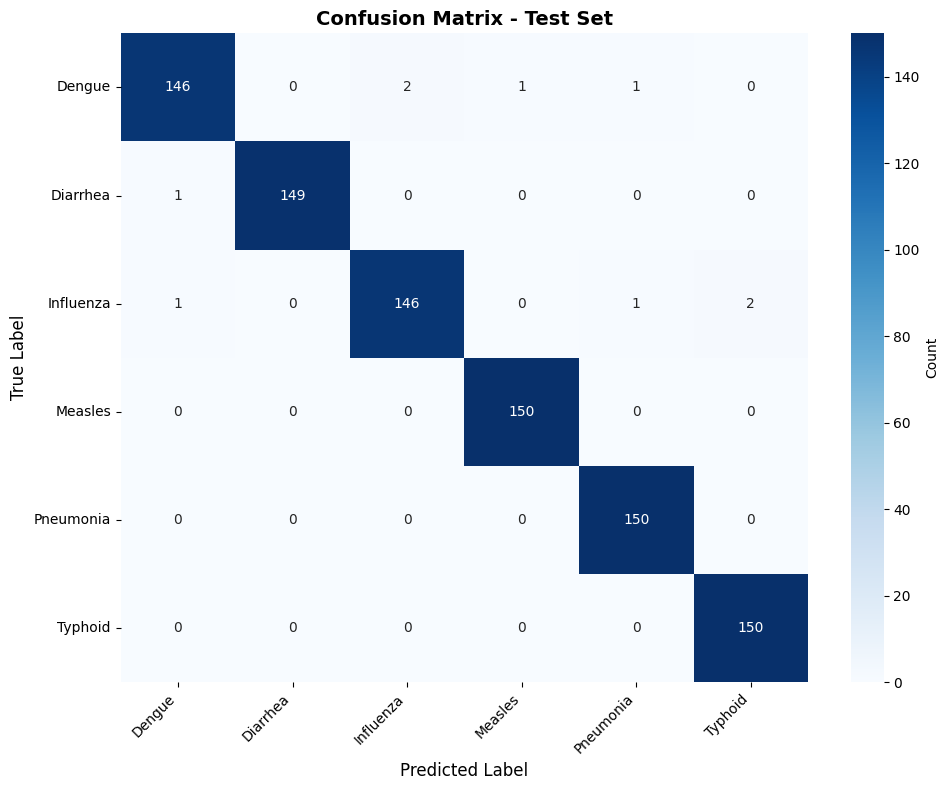

In [29]:
# Generate and plot confusion matrix
print("\n📊 Generating confusion matrix...")

cm = confusion_matrix(y_true, y_pred)
cm_labels = [str(id2label[i]) for i in range(len(id2label))]

# Create figure
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=cm_labels,
    yticklabels=cm_labels,
    cbar_kws={'label': 'Count'}
)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix - Test Set", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save figure
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
print("✅ Confusion matrix saved to: confusion_matrix.png")
plt.show()


In [30]:
# import shutil
# import os

# # Add this BEFORE your K-Fold loop
# folders_to_clean = [
#     './optuna_trials',          # Hyperparameter search artifacts
#     './logs',                    # Training logs
#     drive_save_path,             # Your Google Drive model path (if you want to clear it)
#     './results_fold_1',
#     './results_fold_2',
#     './results_fold_3',
#     './results_fold_4',
#     './results_fold_5'
# ]

# print("🧹 Cleaning up directories to free space...\n")
# for folder in folders_to_clean:
#     if os.path.exists(folder):
#         try:
#             shutil.rmtree(folder)
#             print(f"✅ Removed: {folder}")
#         except Exception as e:
#             print(f"⚠️ Could not remove {folder}: {e}")
#     else:
#         print(f"ℹ️  Not found: {folder}")

In [31]:
from sklearn.model_selection import StratifiedKFold
from transformers import Trainer, TrainingArguments, AutoModelForSequenceClassification
import numpy as np
from sklearn.metrics import classification_report, accuracy_score
import shutil
import os

# Define the number of folds
n_splits = 5
# Use StratifiedKFold to ensure balanced disease distribution in each fold
kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Initialize lists to store evaluation results
all_accuracy_scores = []
all_classification_reports = []

# Convert the dataset to a pandas DataFrame for easier splitting
dataset_df = tokenized_dataset["train"].to_pandas()

# Get the labels for stratification
fold_labels = dataset_df['labels']

for fold, (train_index, val_index) in enumerate(kf.split(dataset_df, fold_labels)):
    folder_path = f"results_fold_{fold+1}"

    print("Removing previous cross val folder to save space...")

    if os.path.exists(folder_path):
        shutil.rmtree(folder_path)
        print(f"Removed folder: {folder_path}")
    else:
        print(f"Folder not found: {folder_path}")

    print(f"--- Fold {fold+1}/{n_splits} ---")

    # Create train and validation datasets for the current fold
    train_dataset_fold = tokenized_dataset["train"].select(train_index)
    val_dataset_fold = tokenized_dataset["train"].select(val_index)

    # Re-initialize the model for each fold to ensure a fresh start
    model = AutoModelForSequenceClassification.from_pretrained(
        model_id,
        num_labels=num_labels,
        label2id=label2id,
        id2label=id2label,
        attention_probs_dropout_prob=0.1,
        hidden_dropout_prob=0.1,
        classifier_dropout=0.1,
    )
    model.gradient_checkpointing_enable()

    # Define training arguments for the current fold
    # Using the best hyperparameters found in the hyperparameter search
    training_args_fold = TrainingArguments(
        output_dir=f"./results_fold_{fold+1}",
        learning_rate=best_run.hyperparameters["learning_rate"],
        per_device_train_batch_size=best_run.hyperparameters["per_device_train_batch_size"],
        weight_decay=best_run.hyperparameters["weight_decay"],

        # Match final training configuration:
        num_train_epochs=8,
        warmup_steps=int((len(train_dataset_fold) // best_run.hyperparameters["per_device_train_batch_size"]) * 10 * 0.1),
        lr_scheduler_type="cosine",
        label_smoothing_factor=0.1,
        max_grad_norm=1.0,

        eval_strategy="epoch",
        save_strategy="no",
        load_best_model_at_end=False,
        logging_strategy="epoch",
        report_to="none",

        # Memory optimizations
        fp16=True,
        gradient_accumulation_steps=2,
        dataloader_pin_memory=False,
    )

    # Create Trainer for the current fold
    trainer_fold = Trainer(
        model=model,
        args=training_args_fold,
        train_dataset=train_dataset_fold,
        eval_dataset=val_dataset_fold,
        compute_metrics=lambda eval_pred: {"accuracy": (eval_pred.predictions.argmax(-1) == eval_pred.label_ids).mean()},
        data_collator=data_collator,
    )

    # Train the model for the current fold
    trainer_fold.train()

    # Evaluate the model on the validation data for the current fold
    fold_predictions, fold_true_labels, fold_metrics = trainer_fold.predict(val_dataset_fold)
    y_pred_fold = np.argmax(fold_predictions, axis=1)
    y_val_fold = np.array(fold_true_labels)

    # Calculate and store accuracy and classification report
    accuracy_fold = accuracy_score(y_val_fold, y_pred_fold)
    report_fold = classification_report(y_val_fold, y_pred_fold, target_names=[str(id2label[i]) for i in range(num_labels)])

    all_accuracy_scores.append(accuracy_fold)
    all_classification_reports.append(report_fold)

    print(f"Accuracy for Fold {fold+1}: {accuracy_fold}")
    print(f"Classification Report for Fold {fold+1}:\n{report_fold}")

# Print average accuracy across all folds
print("\n--- Overall Results ---")
print(f"Average Accuracy across {n_splits} folds: {np.mean(all_accuracy_scores)}")

# Optionally, print classification reports for each fold
print("\n--- Classification Reports for Each Fold ---")
for fold, report in enumerate(all_classification_reports):
    print(f"Classification Report for Fold {fold+1}:\n{report}")


Removing previous cross val folder to save space...
Removed folder: results_fold_1
--- Fold 1/5 ---


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1592.53it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: jcblaise/roberta-tagalog-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the c

Epoch,Training Loss,Validation Loss,Accuracy
1,2.489569,0.547211,0.950000
2,1.030247,0.511039,0.969048
3,0.915383,0.495045,0.971429
4,0.872346,0.474253,0.982143
5,0.852307,0.467725,0.984524
6,0.847265,0.470132,0.983333
7,0.845624,0.467825,0.985714
8,0.845222,0.467817,0.985714


Accuracy for Fold 1: 0.9857142857142858
Classification Report for Fold 1:
              precision    recall  f1-score   support

      Dengue       0.99      0.94      0.97       140
    Diarrhea       0.98      1.00      0.99       140
   Influenza       0.98      0.97      0.97       140
     Measles       0.99      1.00      1.00       140
   Pneumonia       0.99      1.00      1.00       140
     Typhoid       0.98      1.00      0.99       140

    accuracy                           0.99       840
   macro avg       0.99      0.99      0.99       840
weighted avg       0.99      0.99      0.99       840

Removing previous cross val folder to save space...
Removed folder: results_fold_2
--- Fold 2/5 ---


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1542.64it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: jcblaise/roberta-tagalog-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the c

...

Epoch,Training Loss,Validation Loss,Accuracy
1,2.522613,0.528831,0.972619
2,1.018995,0.503415,0.971429
3,0.907933,0.491588,0.977381
4,0.873489,0.469286,0.978571
5,0.848753,0.467120,0.980952
6,0.847084,0.466889,0.985714
7,0.845416,0.465978,0.985714
8,0.845215,0.465904,0.985714


Accuracy for Fold 4: 0.9857142857142858
Classification Report for Fold 4:
              precision    recall  f1-score   support

      Dengue       0.99      0.97      0.98       140
    Diarrhea       1.00      1.00      1.00       140
   Influenza       0.98      0.97      0.97       140
     Measles       0.99      1.00      0.99       140
   Pneumonia       0.99      0.97      0.98       140
     Typhoid       0.98      1.00      0.99       140

    accuracy                           0.99       840
   macro avg       0.99      0.99      0.99       840
weighted avg       0.99      0.99      0.99       840

Removing previous cross val folder to save space...
Removed folder: results_fold_5
--- Fold 5/5 ---


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1531.35it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: jcblaise/roberta-tagalog-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the c

Epoch,Training Loss,Validation Loss,Accuracy
1,2.553172,0.636941,0.938095
2,0.999791,0.574282,0.948810
3,0.918838,0.516627,0.963095
4,0.871301,0.515649,0.966667
5,0.859758,0.494213,0.973810
6,0.848308,0.494900,0.975000
7,0.845450,0.500304,0.970238
8,0.845340,0.500665,0.970238


Accuracy for Fold 5: 0.9702380952380952
Classification Report for Fold 5:
              precision    recall  f1-score   support

      Dengue       0.94      0.96      0.95       140
    Diarrhea       0.99      0.98      0.98       140
   Influenza       0.96      0.91      0.93       140
     Measles       0.99      1.00      0.99       140
   Pneumonia       0.96      0.97      0.96       140
     Typhoid       0.99      1.00      1.00       140

    accuracy                           0.97       840
   macro avg       0.97      0.97      0.97       840
weighted avg       0.97      0.97      0.97       840


--- Overall Results ---
Average Accuracy across 5 folds: 0.983095238095238

--- Classification Reports for Each Fold ---
Classification Report for Fold 1:
              precision    recall  f1-score   support

      Dengue       0.99      0.94      0.97       140
    Diarrhea       0.98      1.00      0.99       140
   Influenza       0.98      0.97      0.97       140
     Measl

# 🧪 Inference Testing

Test the model with hand-crafted symptom descriptions in Filipino to verify it works correctly on real-world inputs.

In [32]:
from transformers import pipeline
import torch

print("🤖 Loading inference pipeline...\n")

# Load from the Hugging Face Hub model
hf_model_id = "notlath/RoBERTa-Tagalog-base-Symptom2Disease_WITH-DROPOUT-42"
classifier = pipeline(
    "text-classification",
    model=hf_model_id,
    device=0 if torch.cuda.is_available() else -1
)

def get_label_name(raw_label):
    """Convert LABEL_X / integer strings to the actual disease name."""
    if isinstance(raw_label, str) and raw_label.upper().startswith("LABEL_"):
        idx = int(raw_label.split("_")[1])
        return id2label.get(idx, raw_label)
    if isinstance(raw_label, str) and raw_label.isdigit():
        return id2label.get(int(raw_label), raw_label)
    return raw_label

# Test samples (formal Filipino symptom descriptions)
test_cases = {
    "Dengue": "Biglaan po ang taas ng lagnat ko at halos hindi ako makabangon sa sakit ng katawan at kasu-kasuan. Masakit din po ang likod ng mga mata ko kapag ginalaw ko. Napansin ko na may mga pulang pantal na lumabas sa balat ko at medyo dumudugo ang gilagid ko.",

    "Diarrhea": "Kanina pa po sumasakit ang tiyan ko at pabalik-balik ako sa banyo. Napansin ko na matubig ang dumi ko pero may halong sariwang dugo at uhog. Pakiramdam ko ay nandidiri ang sikmura ko at nanghihina ako.",

    "Typhoid": "Ilang araw na po akong may lagnat na parang tumataas habang tumatagal. Wala akong ganang kumain at laging masakit ang ulo ko. Masakit din ang tiyan ko at pakiramdam ko ay sobrang bagal ng kilos ko at laging pagod.",

    "Measles": "Nagsimula sa ubo, sipon, at pulang mata na nagluluha. Pagkalipas ng ilang araw, nilagnat ako at tinubuan ng mga pantal simula sa likod ng tenga na kumalat sa buong katawan. May nakita rin akong maliliit na puting tuldok sa loob ng pisngi ko.",

    "Influenza": "Bigla na lang sumama ang pakiramdam ko kanina, giniginaw ako at ang taas ng lagnat. Sobrang sakit ng kalamnan ko, parang binugbog. May tuyong ubo rin ako at sobrang kati at sakit ng lalamunan ko.",

    "Pneumonia": "Nahihirapan akong huminga at mabilis mapagod kahit kaunting kilos lang. May ubo ako na malalim at may kasamang madilaw o berdeng plema. Tuwing humihinga ako nang malalim, kumikirot ang dibdib ko at nilalagnat ako tuwing gabi."
}

print("="*60)
print("INFERENCE TEST RESULTS")
print("="*60)

for expected_disease, symptom_text in test_cases.items():
    result = classifier(symptom_text)[0]
    predicted_label = get_label_name(result['label'])
    confidence = result['score']

    status = "✅" if predicted_label == expected_disease else "❌"

    print(f"\n{status} Expected: {expected_disease}")
    print(f"   Predicted: {predicted_label} (confidence: {confidence:.2%})")
    print(f"   Input: {symptom_text[:80]}...")

print("\n" + "="*60)


🤖 Loading inference pipeline...



Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1305.96it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              


INFERENCE TEST RESULTS

✅ Expected: Dengue
   Predicted: Dengue (confidence: 93.43%)
   Input: Biglaan po ang taas ng lagnat ko at halos hindi ako makabangon sa sakit ng kataw...

✅ Expected: Diarrhea
   Predicted: Diarrhea (confidence: 83.56%)
   Input: Kanina pa po sumasakit ang tiyan ko at pabalik-balik ako sa banyo. Napansin ko n...

❌ Expected: Typhoid
   Predicted: Dengue (confidence: 91.43%)
   Input: Ilang araw na po akong may lagnat na parang tumataas habang tumatagal. Wala akon...

✅ Expected: Measles
   Predicted: Measles (confidence: 93.75%)
   Input: Nagsimula sa ubo, sipon, at pulang mata na nagluluha. Pagkalipas ng ilang araw, ...

✅ Expected: Influenza
   Predicted: Influenza (confidence: 93.54%)
   Input: Bigla na lang sumama ang pakiramdam ko kanina, giniginaw ako at ang taas ng lagn...

✅ Expected: Pneumonia
   Predicted: Pneumonia (confidence: 93.84%)
   Input: Nahihirapan akong huminga at mabilis mapagod kahit kaunting kilos lang. May ubo ...



# 📦 Model Archival

Create a zip archive of the final model for backup and offline deployment.

In [33]:
import shutil
import os

archive_name = "RoBERTa_Tagalog_Symptom2Disease_Final_Model"

if not os.path.exists(drive_save_path):
    print(f"❌ Model directory not found: {drive_save_path}")
    print("   Run the final training cell first to save the model.")
else:
    print(f"📦 Creating model archive from: {drive_save_path}")
    shutil.make_archive(archive_name, 'zip', drive_save_path)
    print(f"✅ Model archived to: {archive_name}.zip")


📦 Creating model archive from: ./final_model
✅ Model archived to: RoBERTa_Tagalog_Symptom2Disease_Final_Model.zip


# 📈 Training Summary

## Model Performance

**Final Results:**
- Architecture: RoBERTa-Tagalog-base (125M parameters)
- Task: Multi-class symptom→disease classification (4 diseases)
- Dataset: Filipino symptom descriptions
- Test Accuracy: See evaluation results above

**Key Features:**
- ✅ **No data leakage**: Stratified splits with integrity verification
- ✅ **Dropout regularization**: 0.1 across all layers
- ✅ **Hyperparameter optimization**: Optuna with 10 trials
- ✅ **Extended training**: 10 epochs with cosine LR schedule
- ✅ **Best checkpoint selection**: Based on validation accuracy

**Training Configuration:**
- Learning rate: Optimized via Optuna (typically 3-5e-5)
- Batch size: Optimized via Optuna (16/32/64)
- Weight decay: Optimized via Optuna (0.15-0.35)
- Warmup: 10% of total steps
- Label smoothing: 0.1
- Gradient clipping: 1.0

**Reproducibility:**
- Random seed: 42 (fixed across all operations)
- Dataset version: `notlath/fil_dataset`
- Base model: `jcblaise/roberta-tagalog-base`

## Next Steps

1. **Model Card**: Update HF Hub with complete documentation
2. **Error Analysis**: Review confusion matrix for systematic errors
3. **Deployment**: Integrate into production pipeline
4. **Monitoring**: Track model performance on real-world data
5. **Iteration**: Collect feedback and retrain with expanded data